In [49]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import glob
import scipy.optimize as so
import astropy.constants as c
sys.path.append('/home/c4011027/PhD_stuff/SPAMMS')
import spamms as sp
from matplotlib.collections import LineCollection, PolyCollection
from matplotlib import cm, colors
import matplotlib.animation as animation
plt.rcParams['figure.dpi'] = 100
print(sys.path)
from pprint import pprint 

['/home/c4011027/PhD_stuff/SPAMMS/notebooks', '/home/c4011027/SpecFANN', '/home/c4011027/PhD_stuff/SPAMMS/notebooks', '/home/c4011027/anaconda3/envs/spamms/lib/python310.zip', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10/lib-dynload', '', '/home/c4011027/anaconda3/envs/spamms/lib/python3.10/site-packages', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS', '/home/c4011027/PhD_stuff/SPAMMS']


In [50]:
input_file = '/home/c4011027/PhD_stuff/SPAMMS/notebooks/input_macro_test.txt'
fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
times, obs_specs = sp.get_obs_spec_and_times(io_dict)

run_dictionaries = sp.create_runs_and_ids(fit_param_values)

Reading input file...


In [51]:
pprint(run_dictionaries) #paramter permutations

[{'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 25.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 0,
  't0': 0.0,
  'teff': 35000.0,
  'v_crit_frac': 0.0,
  'v_macro': -1.0,
  'vsini': -1.0,
  'zeta_R': 350.0,
  'zeta_T': 350.0},
 {'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 25.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 1,
  't0': 0.0,
  'teff': 35000.0,
  'v_crit_frac': 0.25,
  'v_macro': -1.0,
  'vsini': -1.0,
  'zeta_R': 350.0,
  'zeta_T': 350.0},
 {'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 25.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 2,
  't0': 0.0,
  'teff': 35000.0,
  'v_crit_frac': 0.5,
  'v_macro': -1.0,
  'vsini': -1.0,
  'zeta_R': 350.0,
  'zeta_T': 350.0},
 {'A_R': 0.5,
  'gamma': 0.0,
  'inclination': 90.0,
  'mass': 25.0,
  'r_pole': 7.5,
  'requiv': -1.0,
  'rotation_rate': -1.0,
  'run_id': 3,
  't0': 0.0,
  'teff': 35000.0,
  'v

In [52]:
run_dictionary = run_dictionaries[4] # CHANGE THIS TO SELECT WHICH MODEL TO PLOT If using the unchanged input file, 0 is no rotation, 1 is 0.25 crit, and 2 is 0.9 crit
s = sp.run_sb_phoebe_model(times, abund_param_values, io_dict, run_dictionary)
run_dictionary

100%|██████████| 2/2 [00:01<00:00,  1.05it/s]


{'v_macro': -1.0,
 'A_R': 0.5,
 'zeta_R': 350.0,
 'zeta_T': 350.0,
 'teff': 35000.0,
 'vsini': -1.0,
 'rotation_rate': -1.0,
 'v_crit_frac': 0.9,
 'requiv': -1.0,
 'r_pole': 7.5,
 'inclination': 90.0,
 'mass': 25.0,
 't0': 0.0,
 'gamma': 0.0,
 'run_id': 4}

In [53]:
phcb = s['%09.6f'%s['times@dataset@lc'].value]

verts = phcb['mesh@primary@mesh01@uvw_elements'].get_value()
teffs = phcb['mesh@primary@mesh01@teffs'].get_value()
mus = phcb['mesh@primary@mesh01@mus'].get_value()
rvs = phcb['rvs@primary@mesh'].get_value()

xs = verts[:, :, 0]
ys = verts[:, :, 1]
zs = verts[:, :, 2]
print(xs.shape, ys.shape, zs.shape)  # [polygon, vertex]

(11406, 3) (11406, 3) (11406, 3)


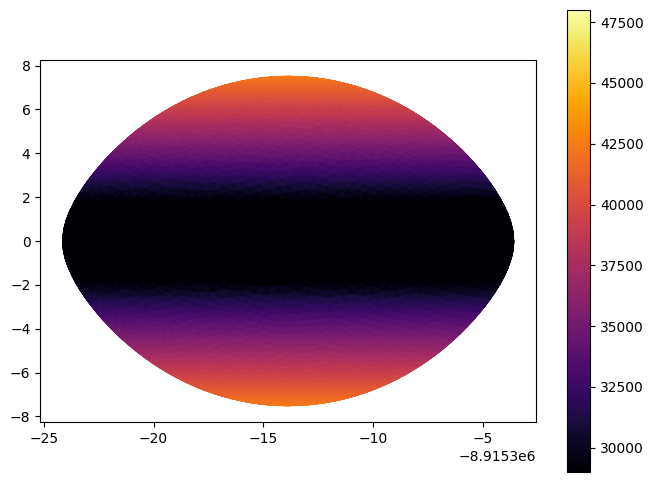

In [54]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)
fc = teffs
norm = colors.Normalize(vmin=np.min(fc), vmax=np.max(fc))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.inferno(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.inferno(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='inferno'), ax=axs)
plt.show()

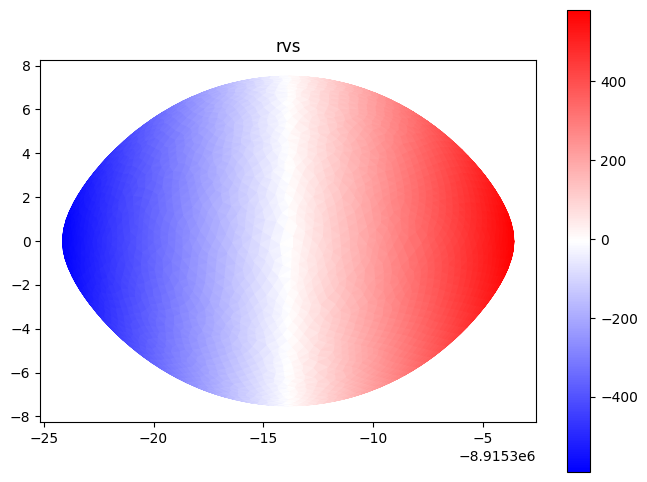

In [55]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)
fc = rvs
norm = colors.Normalize(vmin=np.min(fc), vmax=np.max(fc))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('rvs')
plt.show()

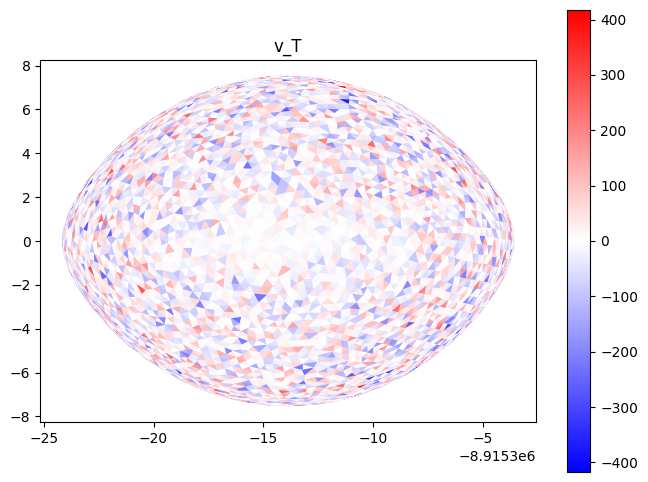

In [56]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)


zeta_T = np.random.normal(0, 250, size=inds.shape[0])

#rng = np.random.default_rng(30)
#theta_T = rng.vonmises(mu=10, kappa=1.0* np.pi, size=mus.shape[0])

theta_T = np.random.uniform(0, 2*np.pi, size=inds.shape[0])
theta_mu = np.arccos(mus)
v_T = 0.5 * zeta_T * np.sin(theta_mu) * np.cos(theta_T)


fc = v_T
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('v_T')
plt.show()

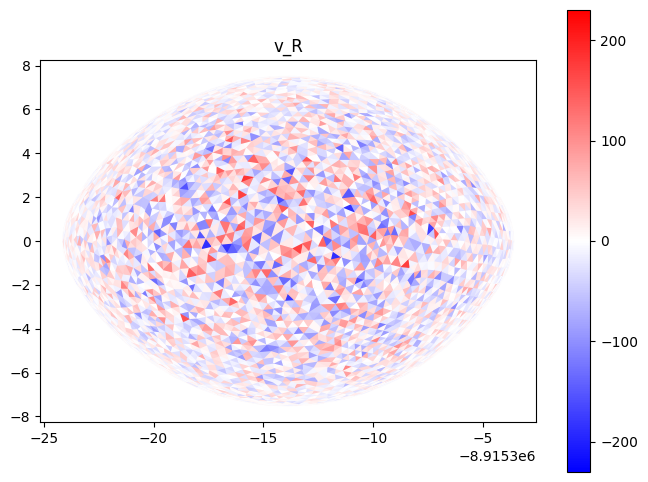

In [57]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)


zeta_R = np.random.normal(0, 250, size=inds.shape[0])
v_R = 0.5 * zeta_R * mus


fc = v_R
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('v_R')
plt.show()

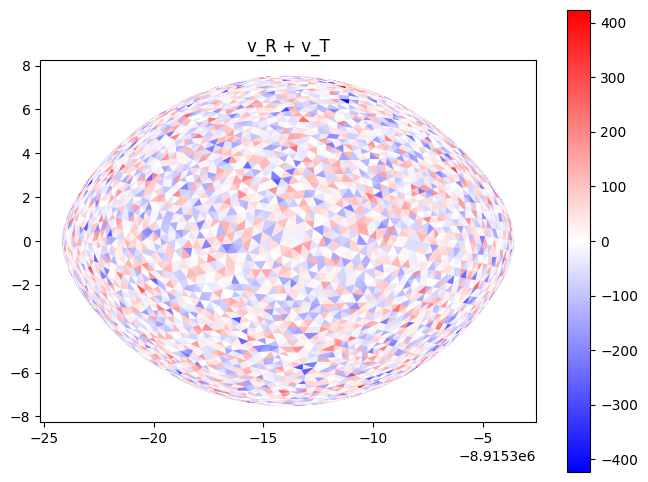

In [58]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)

fc = v_R + v_T
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.title('v_R + v_T')
plt.show()

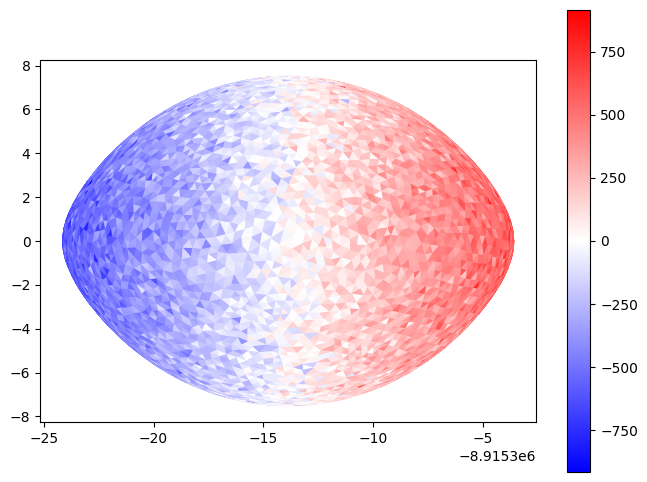

In [59]:
pccall = PolyCollection
polygons = np.concatenate((xs[:,:,np.newaxis], ys[:,:,np.newaxis]), axis=2)


viss = phcb['visibilities@primary'].get_value()
inds = (phcb['mesh@primary@mesh01@mus'].get_value() >= 0)
inds = (viss > 0)

fc = v_R + v_T + rvs
norm = colors.Normalize(vmin=-1 * np.max(np.abs(fc)), vmax=np.max(np.abs(fc)))

z_values = phcb['ws@primary'].get_value()
zinds = np.argsort(z_values[inds])

# norm = colors.Normalize(vmin=29000, vmax=48000)
pc = pccall(polygons[inds][zinds],
            edgecolors=cm.bwr(norm(fc[inds][zinds])),
#             edgecolors='black',
            facecolors=cm.bwr(norm(fc[inds][zinds])))
fig, axs = plt.subplots(1,1, figsize = (8,6))
axs.add_collection(pc)
axs.set_aspect('equal')
axs.axis('scaled')
# axs[0].autoscale_view()
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs)
plt.show()

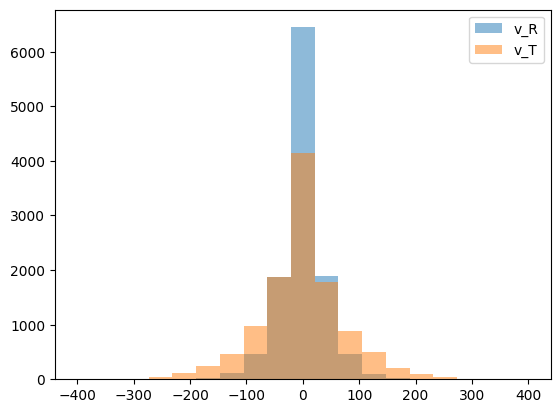

In [60]:
bins = np.linspace(-400, 400, 20)
plt.hist(v_R, alpha=0.5, bins=bins, label='v_R')
plt.hist(v_T, alpha=0.5, bins=bins, label='v_T')
plt.legend(loc='upper right')
plt.show()

In [61]:
print(np.std(v_R), np.std(v_T))

38.3284904683163 75.6056318195358


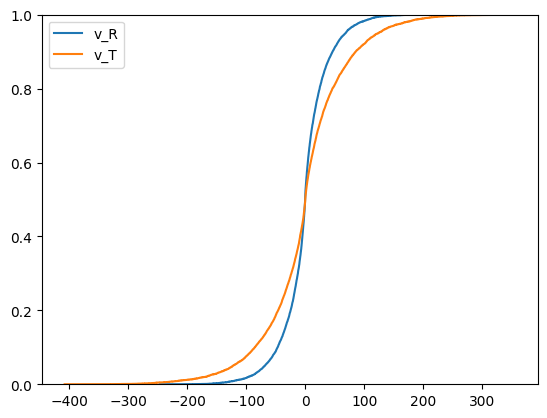

In [14]:
plt.ecdf(v_R, label='v_R')
plt.ecdf(v_T, label='v_T')
plt.legend(loc='upper left')
plt.show()

#### wrapping up together

In [32]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib import cm, colors
sys.path.append('/home/c4011027/PhD_stuff/SPAMMS')
import spamms as sp
DEFAULT_TEMP_CMAP = "inferno"
DEFAULT_VEL_CMAP = "bwr"

def plot_total_velocity_field_with_hist(phcb,A_R=0.5,zeta_R_mean=0.0,zeta_R_std=150.0,zeta_T_mean=0.0,zeta_T_std=250.0,seed=None,figsize=(16, 5)):

    rng = np.random.default_rng(seed)
    verts = phcb['mesh@primary@mesh01@uvw_elements'].get_value()
    mus   = phcb['mesh@primary@mesh01@mus'].get_value()
    rvs   = phcb['rvs@primary@mesh'].get_value()
    viss  = phcb['visibilities@primary'].get_value()
    ws    = phcb['ws@primary'].get_value()
    xs = verts[:, :, 0]
    ys = verts[:, :, 1]
    polygons = np.concatenate((xs[:, :, np.newaxis], ys[:, :, np.newaxis]), axis=2)
    inds = (viss > 0)

    zeta_R = rng.normal(loc=zeta_R_mean, scale=zeta_R_std, size=mus.shape[0])
    v_R = A_R * zeta_R * mus
    zeta_T = rng.normal(loc=zeta_T_mean, scale=zeta_T_std, size=mus.shape[0])
    theta_T = rng.uniform(0.0, 2.0 * np.pi, size=mus.shape[0])
    theta_mu = np.arccos(np.clip(mus, -1.0, 1.0))
    v_T = (1.0 - A_R) * zeta_T * np.sin(theta_mu) * np.cos(theta_T)
    fc = v_R + v_T + rvs

    zinds = np.argsort(ws[inds])
    vmax = np.max(np.abs(fc[inds]))
    norm = colors.Normalize(vmin=-vmax, vmax=vmax)
    fig, axs = plt.subplots(1, 2,figsize=figsize,gridspec_kw={'width_ratios': [1, 2]})

    pc = PolyCollection(polygons[inds][zinds],edgecolors=cm.bwr(norm(fc[inds][zinds])),facecolors=cm.bwr(norm(fc[inds][zinds])))
    axs[0].add_collection(pc)
    axs[0].set_aspect('equal')
    axs[0].axis('scaled')
    axs[0].set_title('Total local velocity field', fontsize=14)
    axs[0].set_xlabel('x', fontsize=12)
    axs[0].set_ylabel('y', fontsize=12)
    axs[0].tick_params(axis='both', which='major', labelsize=11)
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bwr'), ax=axs[0], pad=0.02)
    cbar.set_label('Velocity', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    zetaR_vis = zeta_R[inds]
    zetaT_vis = zeta_T[inds]
    vR_vis = v_R[inds]
    vT_vis = v_T[inds]
    vmax_hist = np.max(np.abs(np.concatenate([zetaR_vis, zetaT_vis, vR_vis, vT_vis])))
    bins = np.linspace(-vmax_hist, vmax_hist, 36)
    axs[1].hist( vR_vis,bins=bins,histtype='stepfilled',alpha=0.40,linewidth=1.5,label=r'$v_R$')
    axs[1].hist(vT_vis,bins=bins,histtype='stepfilled',alpha=0.40,linewidth=1.5,label=r'$v_T$')
    axs[1].hist(zetaR_vis,bins=bins,histtype='step',linewidth=2.0,linestyle='-',label=r'$\zeta_R$')
    axs[1].hist(zetaT_vis,bins=bins,histtype='step',linewidth=2.0,linestyle='--',label=r'$\zeta_T$')
    axs[1].axvline(0, color='k', ls='--', lw=1.0, alpha=0.7)
    axs[1].set_title('Intrinsic vs projected distributions', fontsize=14)
    axs[1].set_xlabel('Velocity', fontsize=12)
    axs[1].set_ylabel('Count', fontsize=12)
    axs[1].tick_params(axis='both', which='major', labelsize=11)
    axs[1].legend(frameon=False, fontsize=10)
    axs[1].grid(alpha=0.25, linestyle='--')

    plt.tight_layout()
    plt.show()

    return {
        'v_R': v_R,
        'v_T': v_T,
        'v_total': fc,
        'zeta_R': zeta_R,
        'zeta_T': zeta_T,
        'theta_T': theta_T
    }

In [29]:

input_file = '/home/c4011027/PhD_stuff/SPAMMS/notebooks/input_macro_test.txt'
fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
times, obs_specs = sp.get_obs_spec_and_times(io_dict)
run_dictionaries = sp.create_runs_and_ids(fit_param_values)
run_dictionary = run_dictionaries[4]
s = sp.run_sb_phoebe_model(times, abund_param_values, io_dict, run_dictionary)
phcb = s['%09.6f' % s['times@dataset@lc'].value]

Reading input file...


100%|██████████| 2/2 [00:02<00:00,  1.44s/it]


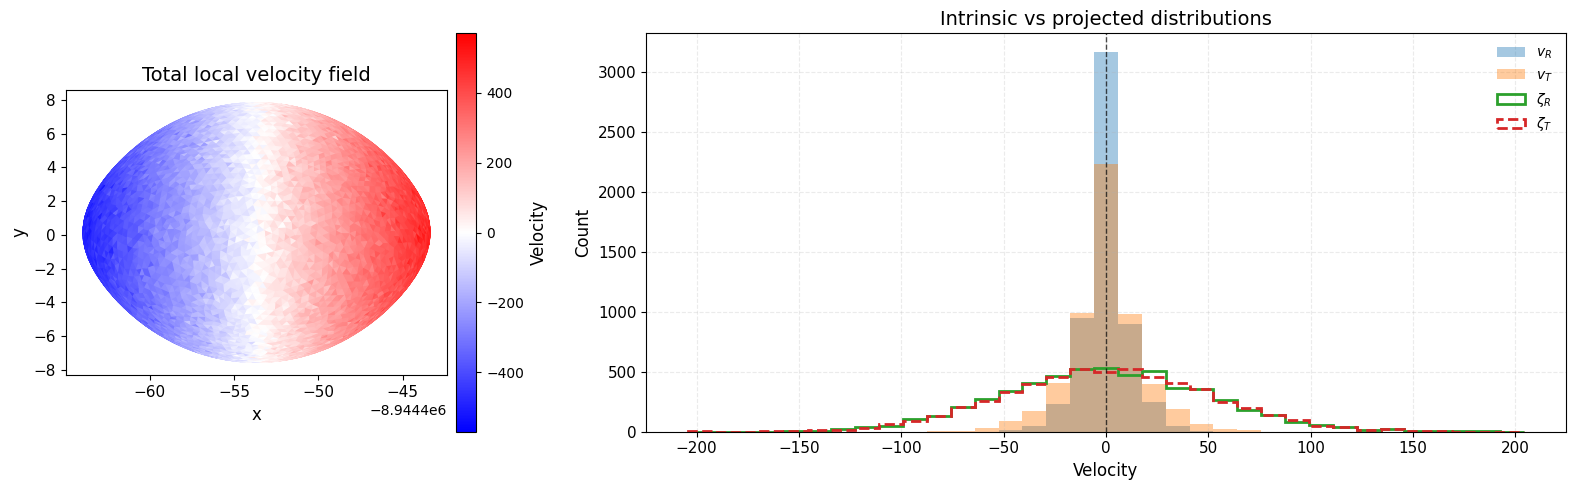

In [33]:
out = plot_total_velocity_field_with_hist(
    phcb,
    A_R=0.4,
    zeta_R_mean=0.0,
    zeta_R_std=50.0,
    zeta_T_mean=0.0,
    zeta_T_std=50.0, seed = None)

#### paramter study

In [38]:
import os
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib import cm, colors

sys.path.append('/home/c4011027/PhD_stuff/SPAMMS')
import spamms as sp

DEFAULT_TEMP_CMAP = "inferno"
DEFAULT_VEL_CMAP = "bwr"


def draw_velocity_surface_and_hist(
    phcb,
    ax_surface,
    ax_hist,
    A_R=0.5,
    zeta_R_mean=0.0,
    zeta_R_std=150.0,
    zeta_T_mean=0.0,
    zeta_T_std=150.0,
    seed=None,
    row_label=None,
    show_colorbar=True
):
    rng = np.random.default_rng(seed)

    verts = phcb['mesh@primary@mesh01@uvw_elements'].get_value()
    mus   = phcb['mesh@primary@mesh01@mus'].get_value()
    rvs   = phcb['rvs@primary@mesh'].get_value()
    viss  = phcb['visibilities@primary'].get_value()
    ws    = phcb['ws@primary'].get_value()

    xs = verts[:, :, 0]
    ys = verts[:, :, 1]
    polygons = np.concatenate((xs[:, :, np.newaxis], ys[:, :, np.newaxis]), axis=2)

    inds = (viss > 0)

    zeta_R = rng.normal(loc=zeta_R_mean, scale=zeta_R_std, size=mus.shape[0])
    v_R = A_R * zeta_R * mus

    zeta_T = rng.normal(loc=zeta_T_mean, scale=zeta_T_std, size=mus.shape[0])
    theta_T = rng.uniform(0.0, 2.0 * np.pi, size=mus.shape[0])
    theta_mu = np.arccos(np.clip(mus, -1.0, 1.0))
    v_T = (1.0 - A_R) * zeta_T * np.sin(theta_mu) * np.cos(theta_T)

    fc = v_R + v_T + rvs

    zinds = np.argsort(ws[inds])
    vmax = np.max(np.abs(fc[inds]))
    norm = colors.Normalize(vmin=-vmax, vmax=vmax)

    pc = PolyCollection(
        polygons[inds][zinds],
        edgecolors=cm.bwr(norm(fc[inds][zinds])),
        facecolors=cm.bwr(norm(fc[inds][zinds]))
    )

    ax_surface.add_collection(pc)
    ax_surface.set_aspect('equal')
    ax_surface.axis('scaled')
    ax_surface.set_xlabel('x', fontsize=10)
    ax_surface.set_ylabel('y', fontsize=10)
    ax_surface.tick_params(axis='both', which='major', labelsize=9)

    if row_label is not None:
        ax_surface.set_title(row_label, fontsize=11)
    else:
        ax_surface.set_title('Total local velocity field', fontsize=11)

    if show_colorbar:
        cbar = ax_surface.figure.colorbar(
            cm.ScalarMappable(norm=norm, cmap='bwr'),
            ax=ax_surface,
            pad=0.02
        )
        cbar.set_label('Velocity', fontsize=10)
        cbar.ax.tick_params(labelsize=8)

    zetaR_vis = zeta_R[inds]
    zetaT_vis = zeta_T[inds]
    vR_vis = v_R[inds]
    vT_vis = v_T[inds]

    vmax_hist = np.max(np.abs(np.concatenate([zetaR_vis, zetaT_vis, vR_vis, vT_vis])))
    bins = np.linspace(-vmax_hist, vmax_hist, 36)

    ax_hist.hist(vR_vis, bins=bins, histtype='stepfilled', alpha=0.40, linewidth=1.2, label=r'$v_R$')
    ax_hist.hist(vT_vis, bins=bins, histtype='stepfilled', alpha=0.40, linewidth=1.2, label=r'$v_T$')
    ax_hist.hist(zetaR_vis, bins=bins, histtype='step', linewidth=1.8, linestyle='-', label=r'$\zeta_R$')
    ax_hist.hist(zetaT_vis, bins=bins, histtype='step', linewidth=1.8, linestyle='--', label=r'$\zeta_T$')
    ax_hist.axvline(0, color='k', ls='--', lw=1.0, alpha=0.7)

    sigma_vR = np.std(vR_vis)
    sigma_vT = np.std(vT_vis)

    txt = (
        rf'$\sigma(v_R)={sigma_vR:.1f}$' '\n'
        rf'$\sigma(v_T)={sigma_vT:.1f}$'
    )

    ax_hist.text(
        0.03, 0.97, txt,
        transform=ax_hist.transAxes,
        ha='left', va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='0.7')
    )

    ax_hist.set_title('Intrinsic vs projected distributions', fontsize=11)
    ax_hist.set_xlabel('Velocity', fontsize=10)
    ax_hist.set_ylabel('Count', fontsize=10)
    ax_hist.tick_params(axis='both', which='major', labelsize=9)
    ax_hist.legend(frameon=False, fontsize=8)
    ax_hist.grid(alpha=0.25, linestyle='--')

    return {
        'v_R': v_R,
        'v_T': v_T,
        'v_total': fc,
        'zeta_R': zeta_R,
        'zeta_T': zeta_T,
        'theta_T': theta_T,
        'sigma_vR_vis': sigma_vR,
        'sigma_vT_vis': sigma_vT,
    }

In [41]:
def plot_total_velocity_field_with_hist(
    phcb,
    A_R=0.5,
    zeta_R_mean=0.0,
    zeta_R_std=150.0,
    zeta_T_mean=0.0,
    zeta_T_std=250.0,
    seed=None,
    figsize=(16, 2)
):
    fig, axs = plt.subplots(
        1, 2,
        figsize=figsize,
        gridspec_kw={'width_ratios': [1, 2]}
    )

    out = draw_velocity_surface_and_hist(
        phcb=phcb,
        ax_surface=axs[0],
        ax_hist=axs[1],
        A_R=A_R,
        zeta_R_mean=zeta_R_mean,
        zeta_R_std=zeta_R_std,
        zeta_T_mean=zeta_T_mean,
        zeta_T_std=zeta_T_std,
        seed=seed,
        row_label='Total local velocity field',
        show_colorbar=True
    )

    plt.tight_layout()
    plt.show()
    return out

In [42]:
def sigma_parameter_study(
    phcb,
    sigma_list=[50, 100, 150, 250, 300, 350, 400, 450, 500],
    A_R=0.5,
    zeta_R_mean=0.0,
    zeta_T_mean=0.0,
    seed=None,
    figsize_per_row=(16, 2)):
    nrows = len(sigma_list)

    fig, axs = plt.subplots(
        nrows, 2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * nrows),
        gridspec_kw={'width_ratios': [1, 2]}
    )

    if nrows == 1:
        axs = np.array([axs])

    outputs = []

    for i, sigma in enumerate(sigma_list):
        out = draw_velocity_surface_and_hist(
            phcb=phcb,
            ax_surface=axs[i, 0],
            ax_hist=axs[i, 1],
            A_R=A_R,
            zeta_R_mean=zeta_R_mean,
            zeta_R_std=sigma,
            zeta_T_mean=zeta_T_mean,
            zeta_T_std=sigma,
            seed=seed,
            row_label=rf'$\sigma_R = \sigma_T = {sigma}$',
            show_colorbar=True
        )
        outputs.append(out)

    plt.tight_layout()
    plt.show()

    return outputs

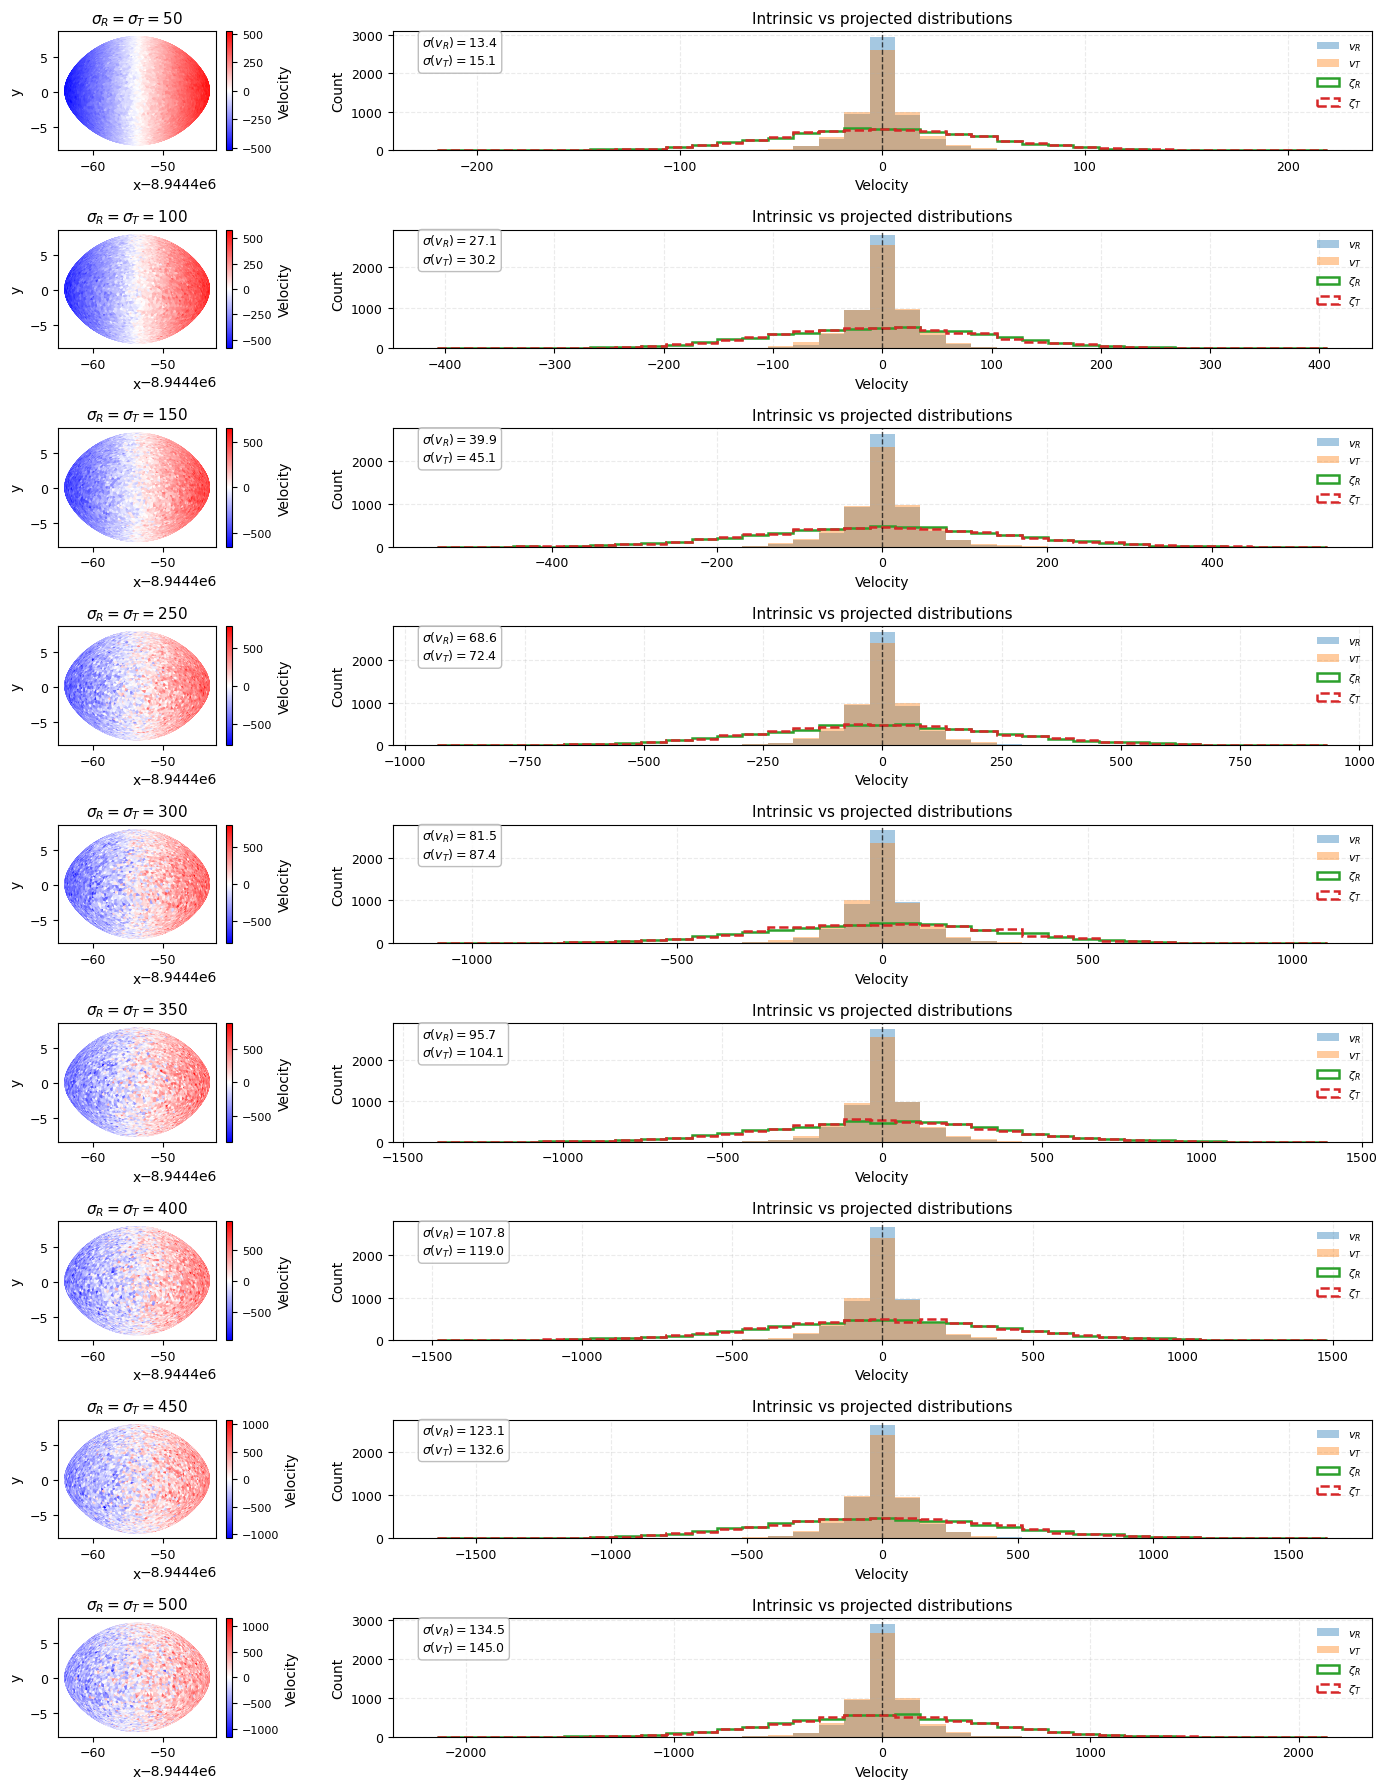

In [43]:
sigma_outputs = sigma_parameter_study(
    phcb,
    sigma_list=[50, 100, 150, 250, 300, 350, 400, 450, 500],
    A_R=0.5,
    seed=None
)

In [64]:
def rotation_parameter_study(
    input_file,
    vcrit_list=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    A_R=0.4,
    zeta_sigma=200.0,
    seed=None,
    figsize_per_row=(16, 2)
):
    fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
    times, obs_specs = sp.get_obs_spec_and_times(io_dict)

    nrows = len(vcrit_list)
    fig, axs = plt.subplots(
        nrows, 2,
        figsize=(figsize_per_row[0], figsize_per_row[1] * nrows),
        gridspec_kw={'width_ratios': [1, 2]}
    )

    if nrows == 1:
        axs = np.array([axs])

    outputs = []

    for i, vcrit in enumerate(vcrit_list):
        fit_params_this = copy.deepcopy(fit_param_values)
        fit_params_this['v_crit_frac'] = [vcrit]

        run_dicts_this = sp.create_runs_and_ids(fit_params_this)
        run_dictionary = run_dicts_this[0]
        print(run_dictionary)
        
        s = sp.run_sb_phoebe_model(times, abund_param_values, io_dict, run_dictionary)
        phcb = s['%09.6f' % s['times@dataset@lc'].value]

        out = draw_velocity_surface_and_hist(
            phcb=phcb,
            ax_surface=axs[i, 0],
            ax_hist=axs[i, 1],
            A_R=A_R,
            zeta_R_mean=0.0,
            zeta_R_std=zeta_sigma,
            zeta_T_mean=0.0,
            zeta_T_std=zeta_sigma,
            seed=seed,
            row_label=rf'$v_{{\rm crit}} = {vcrit:.1f}$',
            show_colorbar=True
        )
        outputs.append({
            'v_crit_frac': vcrit,
            'out': out,
        })

    plt.tight_layout()
    plt.show()

    return outputs

Reading input file...
{'v_macro': -1.0, 'A_R': 0.5, 'zeta_R': 350.0, 'zeta_T': 350.0, 'teff': 35000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0, 'requiv': -1.0, 'r_pole': 7.5, 'inclination': 90.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:03<00:00,  1.76s/it]


{'v_macro': -1.0, 'A_R': 0.5, 'zeta_R': 350.0, 'zeta_T': 350.0, 'teff': 35000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.1, 'requiv': -1.0, 'r_pole': 7.5, 'inclination': 90.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:01<00:00,  1.04it/s]


{'v_macro': -1.0, 'A_R': 0.5, 'zeta_R': 350.0, 'zeta_T': 350.0, 'teff': 35000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.2, 'requiv': -1.0, 'r_pole': 7.5, 'inclination': 90.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


...

100%|██████████| 2/2 [00:01<00:00,  1.08it/s]


{'v_macro': -1.0, 'A_R': 0.5, 'zeta_R': 350.0, 'zeta_T': 350.0, 'teff': 35000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.8, 'requiv': -1.0, 'r_pole': 7.5, 'inclination': 90.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:02<00:00,  1.03s/it]


{'v_macro': -1.0, 'A_R': 0.5, 'zeta_R': 350.0, 'zeta_T': 350.0, 'teff': 35000.0, 'vsini': -1.0, 'rotation_rate': -1.0, 'v_crit_frac': 0.9, 'requiv': -1.0, 'r_pole': 7.5, 'inclination': 90.0, 'mass': 25.0, 't0': 0.0, 'gamma': 0.0, 'run_id': 0}


100%|██████████| 2/2 [00:01<00:00,  1.03it/s]


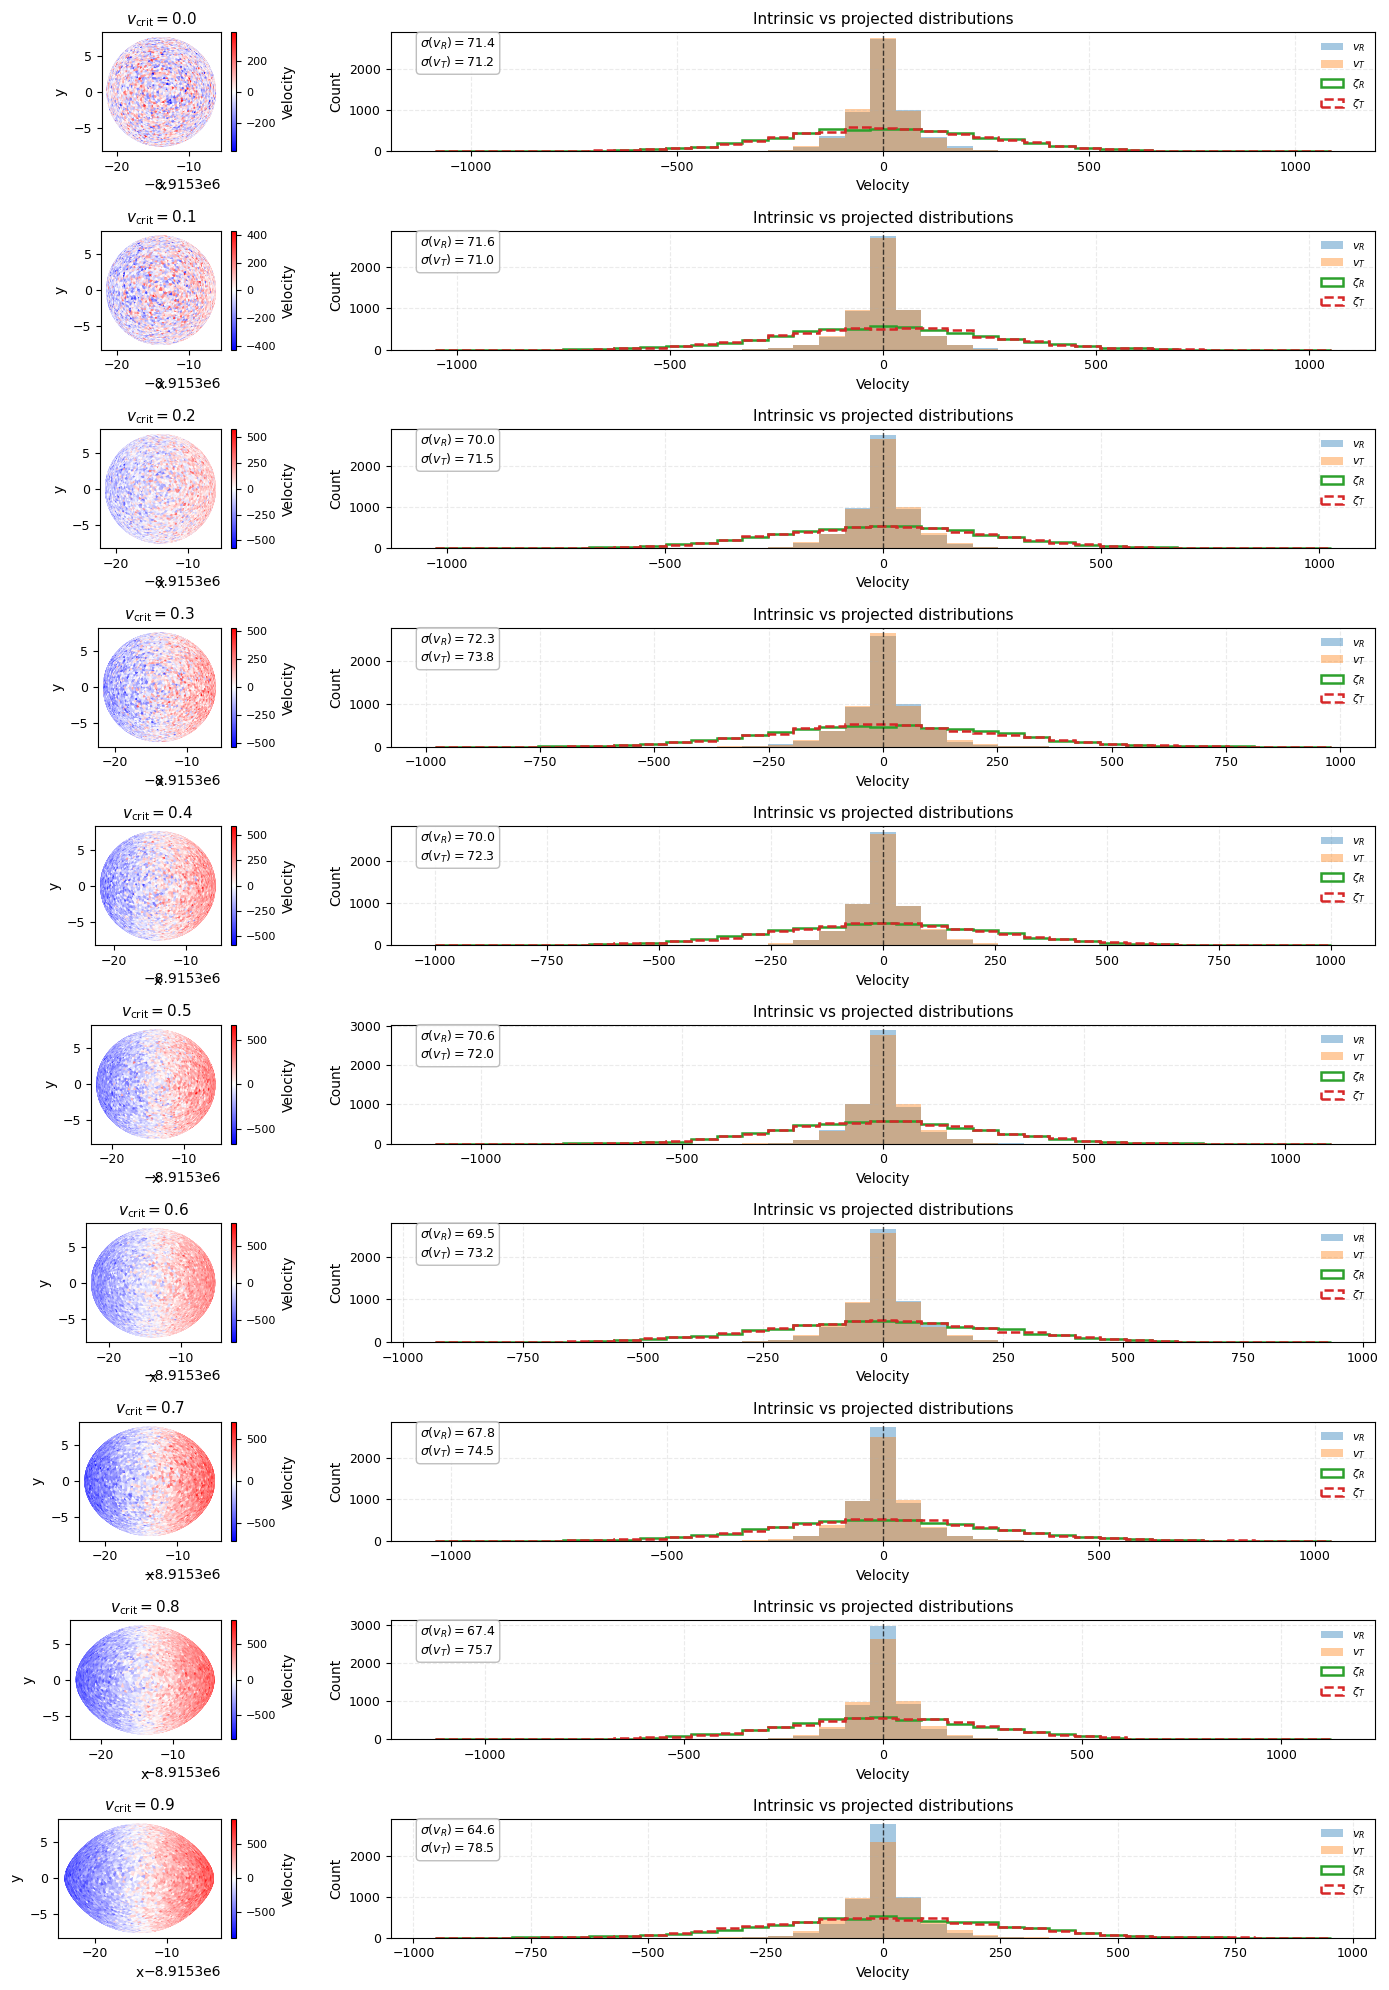

In [65]:
rot_outputs = rotation_parameter_study(
    input_file='/home/c4011027/PhD_stuff/SPAMMS/notebooks/input_macro_test.txt',
    vcrit_list=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    A_R=0.5,
    zeta_sigma=250.0,
    seed=None
)

In [75]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.collections import PolyCollection
from matplotlib import cm, colors
import numpy as np


def draw_velocity_hist_with_surface_inset(
    phcb,
    ax_hist,
    A_R=0.5,
    zeta_R_mean=0.0,
    zeta_R_std=150.0,
    zeta_T_mean=0.0,
    zeta_T_std=250.0,
    seed=None,
    panel_label=None,
    inset_width="32%",
    inset_height="32%"
):
    rng = np.random.default_rng(seed)

    verts = phcb['mesh@primary@mesh01@uvw_elements'].get_value()
    mus   = phcb['mesh@primary@mesh01@mus'].get_value()
    rvs   = phcb['rvs@primary@mesh'].get_value()
    viss  = phcb['visibilities@primary'].get_value()
    ws    = phcb['ws@primary'].get_value()

    xs = verts[:, :, 0]
    ys = verts[:, :, 1]
    polygons = np.concatenate((xs[:, :, np.newaxis], ys[:, :, np.newaxis]), axis=2)
    inds = (viss > 0)

    # ---------------------------------------------------------
    # Velocity field generation
    # ---------------------------------------------------------
    zeta_R = rng.normal(loc=zeta_R_mean, scale=zeta_R_std, size=mus.shape[0])
    v_R = A_R * zeta_R * mus

    zeta_T = rng.normal(loc=zeta_T_mean, scale=zeta_T_std, size=mus.shape[0])
    theta_T = rng.uniform(0.0, 2.0 * np.pi, size=mus.shape[0])
    theta_mu = np.arccos(np.clip(mus, -1.0, 1.0))
    v_T = (1.0 - A_R) * zeta_T * np.sin(theta_mu) * np.cos(theta_T)

    fc = v_R + v_T + rvs

    # ---------------------------------------------------------
    # Histogram panel
    # ---------------------------------------------------------
    zetaR_vis = zeta_R[inds]
    zetaT_vis = zeta_T[inds]
    vR_vis = v_R[inds]
    vT_vis = v_T[inds]

    vmax_hist = np.max(np.abs(np.concatenate([zetaR_vis, zetaT_vis, vR_vis, vT_vis])))
    bins = np.linspace(-vmax_hist, vmax_hist, 36)

    ax_hist.hist(vR_vis, bins=bins, histtype='stepfilled', alpha=0.40, linewidth=1.2, label=r'$v_R$')
    ax_hist.hist(vT_vis, bins=bins, histtype='stepfilled', alpha=0.40, linewidth=1.2, label=r'$v_T$')
    ax_hist.hist(zetaR_vis, bins=bins, histtype='step', linewidth=1.8, linestyle='-', label=r'$\zeta_R$')
    ax_hist.hist(zetaT_vis, bins=bins, histtype='step', linewidth=1.8, linestyle='--', label=r'$\zeta_T$')
    ax_hist.axvline(0, color='k', ls='--', lw=0.9, alpha=0.7)

    sigma_vR = np.std(vR_vis)
    sigma_vT = np.std(vT_vis)

    info_text = (
        rf'$\sigma(v_R)={sigma_vR:.1f}$' '\n'
        rf'$\sigma(v_T)={sigma_vT:.1f}$'
    )

    ax_hist.text(
        0.98, 0.97, info_text,
        transform=ax_hist.transAxes,
        ha='right', va='top',
        fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='0.7')
    )

    if panel_label is not None:
        ax_hist.set_title(panel_label, fontsize=10)

    ax_hist.set_xlabel('Velocity', fontsize=9)
    ax_hist.set_ylabel('Count', fontsize=9)
    ax_hist.tick_params(axis='both', which='major', labelsize=8)
    ax_hist.grid(alpha=0.25, linestyle='--')
    ax_hist.legend(frameon=False, fontsize=7, loc='upper left', bbox_to_anchor=(0.0, 0.68))

    # ---------------------------------------------------------
    # Inset surface map
    # ---------------------------------------------------------
    ax_inset = inset_axes(ax_hist, width=inset_width, height=inset_height, loc='upper left', borderpad=0.8)

    zinds = np.argsort(ws[inds])
    vmax = np.max(np.abs(fc[inds]))
    norm = colors.Normalize(vmin=-vmax, vmax=vmax)

    pc = PolyCollection(
        polygons[inds][zinds],
        edgecolors=cm.bwr(norm(fc[inds][zinds])),
        facecolors=cm.bwr(norm(fc[inds][zinds]))
    )

    ax_inset.add_collection(pc)
    ax_inset.set_aspect('equal')
    ax_inset.axis('scaled')
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_facecolor('white')
    for spine in ax_inset.spines.values():
        spine.set_linewidth(0.8)

    return {
        'v_R': v_R,
        'v_T': v_T,
        'v_total': fc,
        'zeta_R': zeta_R,
        'zeta_T': zeta_T,
        'theta_T': theta_T,
        'sigma_vR_vis': sigma_vR,
        'sigma_vT_vis': sigma_vT,
    }

In [76]:
def inclination_rotation_grid_study(
    input_file,
    inclinations=[10, 20, 30, 40, 50, 60, 70, 80, 90],
    vcrit_list=[0.3, 0.5, 0.7, 0.9],
    A_R=0.4,
    zeta_sigma=200.0,
    seed=None,
    figsize=(18, 26)
):
    fit_param_values, abund_param_values, line_list, io_dict = sp.read_input_file(input_file)
    times, obs_specs = sp.get_obs_spec_and_times(io_dict)

    nrows = len(inclinations)
    ncols = len(vcrit_list)

    fig, axs = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        squeeze=False
    )

    outputs = []

    for i, inc in enumerate(inclinations):
        row_outputs = []

        for j, vcrit in enumerate(vcrit_list):
            fit_params_this = copy.deepcopy(fit_param_values)
            fit_params_this['inclination'] = [inc]
            fit_params_this['v_crit_frac'] = [vcrit]

            run_dicts_this = sp.create_runs_and_ids(fit_params_this)
            run_dictionary = run_dicts_this[0]

            s = sp.run_sb_phoebe_model(times, abund_param_values, io_dict, run_dictionary)
            phcb = s['%09.6f' % s['times@dataset@lc'].value]

            ax_hist = axs[i, j]

            panel_label = rf'$i={inc}^\circ,\ v_{{\rm crit}}={vcrit:.1f}$'

            out = draw_velocity_hist_with_surface_inset(
                phcb=phcb,
                ax_hist=ax_hist,
                A_R=A_R,
                zeta_R_mean=0.0,
                zeta_R_std=zeta_sigma,
                zeta_T_mean=0.0,
                zeta_T_std=zeta_sigma,
                seed=seed,
                panel_label=panel_label
            )

            row_outputs.append({
                'inclination': inc,
                'v_crit_frac': vcrit,
                'out': out
            })

        outputs.append(row_outputs)

    plt.tight_layout()
    plt.show()

    return outputs

In [ ]:
inc_rot_outputs = inclination_rotation_grid_study(
    input_file='/home/c4011027/PhD_stuff/SPAMMS/notebooks/input_macro_test.txt',
    inclinations=[10, 20, 30, 40, 50, 60, 70, 80, 90],
    vcrit_list=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    A_R=0.5,
    zeta_sigma=200.0,
    seed=None,
    figsize=(30, 24)
)

In [ ]:
inc_rot_outputs

In [95]:
def make_sigma_difference_heatmap(inc_rot_outputs):
    """
    Build a single heatmap of:

        Delta = sigma(v_R) - sigma(v_T)

    Interpretation:
        Delta > 0  -> radial component dominates  (red)
        Delta < 0  -> tangential component dominates (blue)

    directly from the already computed inc_rot_outputs.
    """

    # ---------------------------------------------------------
    # Extract inclination + vcrit labels
    # ---------------------------------------------------------
    inclinations = [row[0]['inclination'] for row in inc_rot_outputs]
    vcrit_list = [cell['v_crit_frac'] for cell in inc_rot_outputs[0]]

    nrows = len(inclinations)
    ncols = len(vcrit_list)

    sigma_vR_grid = np.full((nrows, ncols), np.nan)
    sigma_vT_grid = np.full((nrows, ncols), np.nan)

    # ---------------------------------------------------------
    # Extract sigma values from stored outputs
    # ---------------------------------------------------------
    for i, row in enumerate(inc_rot_outputs):
        for j, cell in enumerate(row):
            sigma_vR_grid[i, j] = cell['out']['sigma_vR_vis']
            sigma_vT_grid[i, j] = cell['out']['sigma_vT_vis']

    # ---------------------------------------------------------
    # Main diagnostic:
    # positive  -> radial dominates
    # negative  -> tangential dominates
    # ---------------------------------------------------------
    delta_sigma_grid = sigma_vR_grid - sigma_vT_grid

    # Symmetric colour scale around zero
    vmax = np.max(np.abs(delta_sigma_grid))

    # ---------------------------------------------------------
    # Plot heatmap
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 7))

    im = ax.imshow(
        delta_sigma_grid,
        origin='lower',
        aspect='auto',
        cmap='bwr',          # blue = negative, red = positive
        vmin=-vmax,
        vmax=vmax
    )

    # Axis labels
    ax.set_xticks(np.arange(ncols))
    ax.set_xticklabels(vcrit_list, fontsize=11)

    ax.set_yticks(np.arange(nrows))
    ax.set_yticklabels(inclinations, fontsize=11)

    ax.set_xlabel(r'$v_{\rm crit}$ fraction', fontsize=13)
    ax.set_ylabel(r'Inclination ($^\circ$)', fontsize=13)

    ax.set_title(
        r'$\sigma(v_R) - \sigma(v_T)$',
        fontsize=15
    )

    # ---------------------------------------------------------
    # Write numerical values inside each cell
    # ---------------------------------------------------------
    for i in range(nrows):
        for j in range(ncols):
            value = delta_sigma_grid[i, j]

            ax.text(
                j, i,
                f"{value:.1f}",
                ha='center',
                va='center',
                fontsize=9,
                color='black'
            )

    # ---------------------------------------------------------
    # Colorbar
    # ---------------------------------------------------------
    cbar = fig.colorbar(im, ax=ax)

    cbar.set_label(
        r'$\sigma(v_R) - \sigma(v_T)$',
        fontsize=12
    )

    cbar.ax.tick_params(labelsize=10)

    plt.tight_layout()
    plt.show()

    return {
        'inclinations': inclinations,
        'vcrit_list': vcrit_list,
        'sigma_vR_grid': sigma_vR_grid,
        'sigma_vT_grid': sigma_vT_grid,
        'delta_sigma_grid': delta_sigma_grid
    }

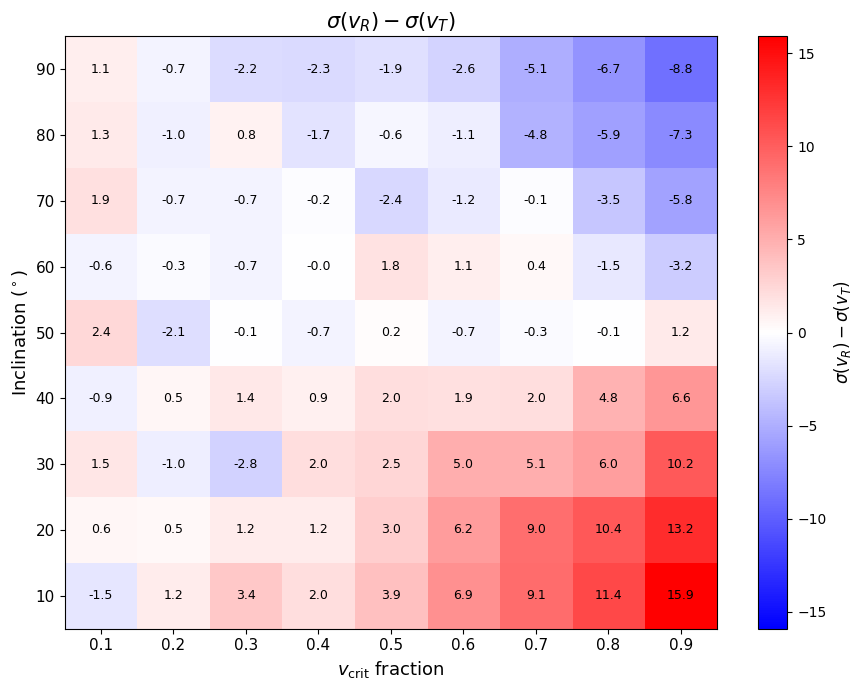

In [96]:
heatmap_results = make_sigma_difference_heatmap(inc_rot_outputs)

In [99]:
def plot_interpolated_sigma_difference_heatmap(heatmap_results, nx=200, ny=200):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import RegularGridInterpolator

    inclinations = np.array(heatmap_results['inclinations'], dtype=float)
    vcrit_list = np.array(heatmap_results['vcrit_list'], dtype=float)
    delta_sigma_grid = np.array(heatmap_results['delta_sigma_grid'], dtype=float)

    # Interpolator over the original coarse grid
    interp = RegularGridInterpolator(
        (inclinations, vcrit_list),
        delta_sigma_grid,
        bounds_error=False,
        fill_value=None
    )

    # Fine grid
    inc_fine = np.linspace(inclinations.min(), inclinations.max(), ny)
    vcrit_fine = np.linspace(vcrit_list.min(), vcrit_list.max(), nx)

    VV, II = np.meshgrid(vcrit_fine, inc_fine)
    pts = np.column_stack([II.ravel(), VV.ravel()])
    delta_fine = interp(pts).reshape(ny, nx)

    vmax = np.max(np.abs(delta_sigma_grid))

    fig, ax = plt.subplots(figsize=(9, 7))

    cf = ax.contourf(
        vcrit_fine,
        inc_fine,
        delta_fine,
        levels=80,
        cmap='bwr',
        vmin=-vmax,
        vmax=vmax
    )

    # Optional: overlay original sampled grid points
    '''
    ax.scatter(
        np.repeat(vcrit_list[np.newaxis, :], len(inclinations), axis=0),
        np.repeat(inclinations[:, np.newaxis], len(vcrit_list), axis=1),
        s=20,
        c='k',
        alpha=0.5
    )
    '''

    ax.set_xlabel(r'$v_{\rm crit}$ fraction', fontsize=13)
    ax.set_ylabel(r'Inclination ($^\circ$)', fontsize=13)
    ax.set_title(r'Interpolated $\sigma(v_R)-\sigma(v_T)$', fontsize=15)

    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label(r'$\sigma(v_R)-\sigma(v_T)$', fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    plt.tight_layout()
    plt.show()

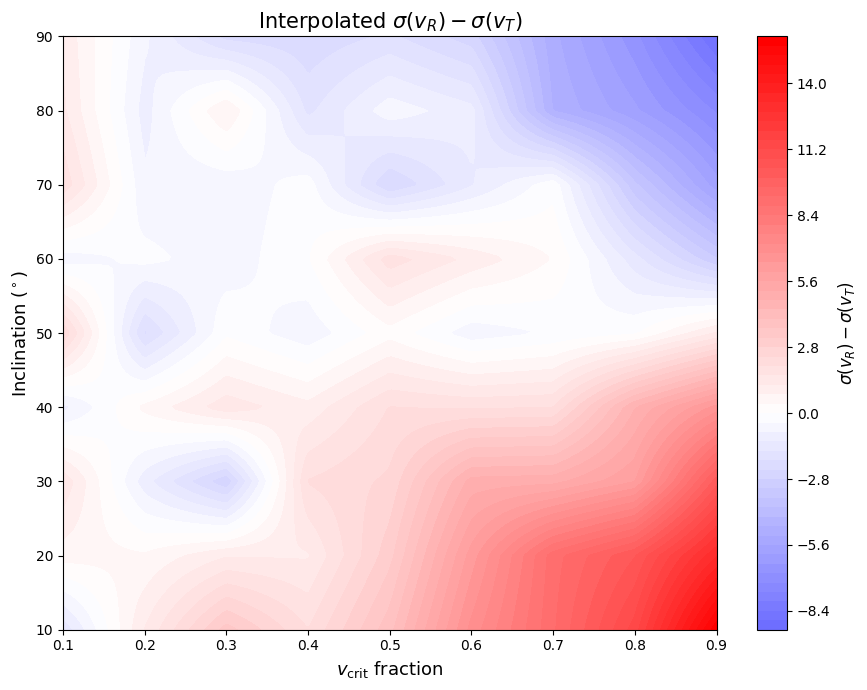

In [100]:
plot_interpolated_sigma_difference_heatmap(heatmap_results)